In [78]:
"""
This script is used to analyze the core losses in differently shaped ferrite cores.
Currently it reads in Comsol simulation results and is used to define the core shapes that will be produced ny CNC machining.
The next step is to conduct measurements and add the corresponding results into this script.
"""
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import logging
import pandas as pd

from hybridmag.utils import comsol_interface as comsol
from meta import paths

# -------------------------
# Logging
# -------------------------
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)

# -------------------------
# Matplotlib settings
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Bitstream Vera Sans", "DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
    "font.size": 10.0,
    "text.latex.preamble": r"\usepackage{upgreek}\usepackage{siunitx}",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Bitstream Vera Serif",
    "mathtext.it": "Bitstream Vera Serif:italic",
    "mathtext.bf": "Bitstream Vera Serif:bold"
})

# -------------------------
# Colors (consistent per curve type)
# -------------------------
color_cuboid = "tab:blue"
color_cylinder = "tab:red"

cm = 1 / 2.54

link2simulations = paths.simulation_data.joinpath("frame_model")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
# Read the total core losses:
df_P_core = comsol.read_df_from_comsol_table(
    link2file=link2simulations.joinpath(f"results/cut.txt"),
    header=["cut_type", "material_type", "f", "P_cut", "P_cut_el"]
)

# Read the core losses inside the core under test:
df_P_cut = comsol.read_df_from_comsol_table(
    link2file=link2simulations.joinpath(f"results/core.txt"),
    header=["cut_type", "material_type", "f", "P_core", "P_core_el"]
)

# Combine the simulation results
df_fem = df_P_core.merge(
    df_P_cut,
    on=["cut_type", "material_type", "f"],
    how="inner",
    validate="one_to_one"
)

# Replace the numbers (from Comsol) by descriptive names:
df_fem["cut_type"] = df_fem["cut_type"].map({
    1: "cylinder",
    2: "cuboid"
})
df_fem["material_type"] = df_fem["material_type"].map({
    1: "full",
    2: "static"
})

print(df_fem)

    cut_type material_type       f     P_cut  P_cut_el     P_core  P_core_el
0   cylinder          full  100000  0.069446  0.007234   0.166891   0.012416
1   cylinder          full  500000  1.121584  0.487288   2.400837   0.826318
2   cylinder          full  900000  5.428604  2.798455  11.008774   4.629337
3   cylinder        static  100000  0.063591  0.001336   0.156807   0.002294
4   cylinder        static  500000  0.669169  0.033424   1.630105   0.057410
5   cylinder        static  900000  2.613605  0.108373   6.356495   0.186165
6     cuboid          full  100000  0.056444  0.001980   0.143718   0.006087
7     cuboid          full  500000  0.692378  0.126712   1.820610   0.391646
8     cuboid          full  900000  2.941066  0.652835   7.819323   2.040333
9     cuboid        static  100000  0.054829  0.000367   0.138749   0.001127
10    cuboid        static  500000  0.574128  0.009173   1.454848   0.028198
11    cuboid        static  900000  2.303445  0.029744   5.828399   0.091430

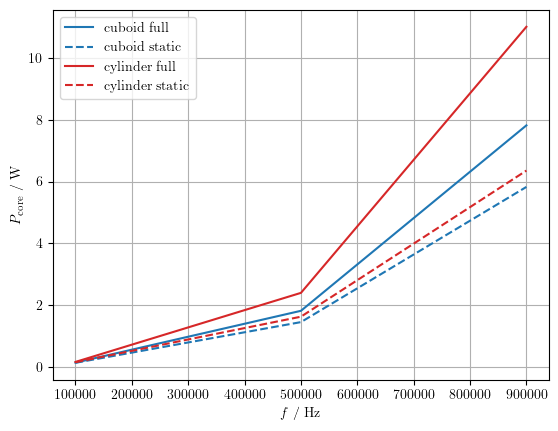

In [80]:
# Plot the measurable (total) core losses of the two configurations
# (static and full material)

styles = {
    "full": "-",
    "static": "--",
}

colors = {
    "cylinder": color_cylinder,
    "cuboid": color_cuboid,
}

for (cut_type, material_type), group in df_fem.sort_values("f").groupby(["cut_type", "material_type"]):
    plt.plot(
        group["f"],
        group["P_core"],
        linestyle=styles[material_type],
        color=colors[cut_type],
        label=f"{cut_type} {material_type}"
    )

plt.legend()
plt.grid(True)
plt.ylabel(r"$P_\mathrm{core}$ / W")
plt.xlabel(r"$f$ / Hz")
plt.show()

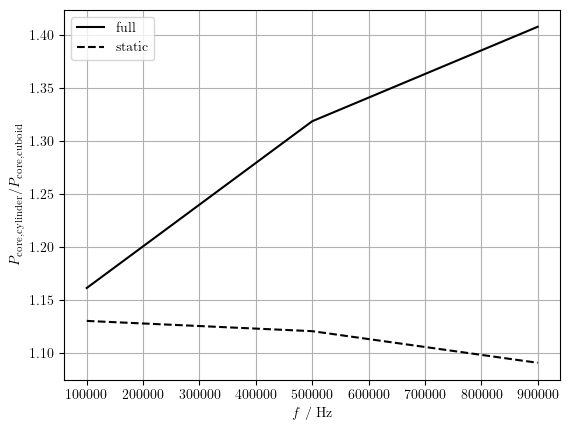

In [81]:
# Plot the relative ratio of the two configurations
# (static and full material)

for material_type, group in df_fem.sort_values("f").groupby("material_type"):
    cyl = group[group["cut_type"] == "cylinder"].sort_values("f")
    cub = group[group["cut_type"] == "cuboid"].sort_values("f")

    plt.plot(
        cyl["f"],
        cyl["P_core"].to_numpy() / cub["P_core"].to_numpy(),
        linestyle=styles[material_type],
        color="k",
        label=f"{material_type}"
    )

plt.legend()
plt.grid(True)
plt.xlabel(r"$f$ / Hz")
plt.ylabel(r"$P_\mathrm{core,cylinder} / P_\mathrm{core,cuboid}$")
plt.show()

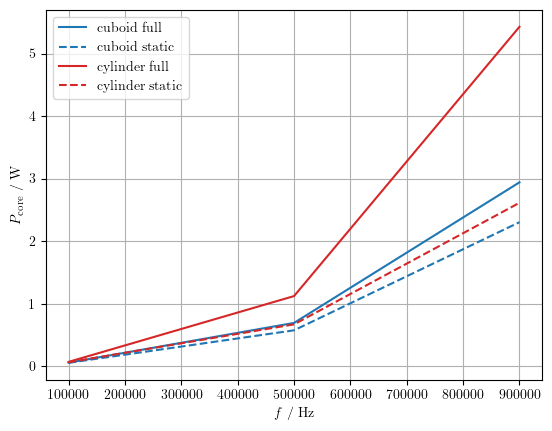

In [82]:
# Plot the non-measurable core losses only in the core under test
# (static and full material)

styles = {
    "full": "-",
    "static": "--",
}

colors = {
    "cylinder": color_cylinder,
    "cuboid": color_cuboid,
}


for (cut_type, material_type), group in df_fem.sort_values("f").groupby(["cut_type", "material_type"]):
    plt.plot(
        group["f"],
        group["P_cut"],
        linestyle=styles[material_type],
        color=colors[cut_type],
        label=f"{cut_type} {material_type}"
    )


plt.legend()
plt.grid(True)
plt.ylabel(r"$P_\mathrm{core}$ / W")
plt.xlabel(r"$f$ / Hz")
plt.show()